# BDD100K — Super-net vs Base-net box-wise confidence analysis

1. **Image-wise mean confidence** (super vs base) over the val set.
2. **Box-wise conf_diff for boxes both models predicted as TP** — for each GT, take the matching prediction from super and from base; both must satisfy IoU≥0.5 + class match. Sort by `conf_super - conf_base` ascending.
3. **Box-wise conf_diff for boxes both models predicted as FP** — predictions that match no GT. Match by spatial overlap between the super FP set and the base FP set (IoU≥0.5 + class match) to identify the same false alarm.
4. **"Both FN" GTs** — GTs neither model recovered as a TP. (FN has no associated prediction box, so we don't plot a conf_diff curve; we show per-image FN counts and the GT-side properties instead.)

Runs both super-net (no skip) and base-net (skip all) over BDD val, accumulates per-GT and per-pred bookkeeping, and plots the requested curves.

In [99]:
# ---- config ----
WEIGHT = "/home/hslee/Desktop/Embedded_AI/context-anydepth-det/anydepth-yolov12/finetuned_bdd100k/30e_SGD0900_bs32_nbs256_1e-3_1e-5_1280-720_singleScale_augNothing_alpha0.6_orig_mAP34.3_33.1.pt"
DATA = "bdd100k.yaml"
IMGSZ = 1280
DEVICE = "cuda:0"
SPLIT = "val"
NMS_CONF = 0.001
NMS_IOU = 0.7
TP_IOU = 0.5         # IoU threshold for TP matching (pred <-> GT, class-matched)
FP_PAIR_IOU = 0.5    # IoU threshold for matching a super FP with a base FP (class-matched)
LIMIT = 0            # 0 = full val set; small int for debugging
OUT_DIR = "./analysis/bdd100k-AnyDepth/super-vs-base-box-confdiff"

In [100]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), ".."))) if os.path.basename(os.getcwd()) == "tools" else None
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

from ultralytics import YOLO
from ultralytics.cfg import get_cfg
from ultralytics.data import build_yolo_dataset
from ultralytics.utils import DEFAULT_CFG_DICT
from ultralytics.data.utils import check_det_dataset
from ultralytics.utils.ops import non_max_suppression, xywh2xyxy
from ultralytics.utils.metrics import box_iou

Path(OUT_DIR).mkdir(parents=True, exist_ok=True)
device = torch.device(DEVICE if torch.cuda.is_available() else "cpu")

In [101]:
# ---- model + data ----
yolo = YOLO(WEIGHT, task="detect")
model = yolo.model.to(device).eval()
num_skip = getattr(model, "num_skippable_layers", 0)
assert num_skip > 0, "AnyDepth model required (num_skippable_layers must be >0)."
nc = int(getattr(model, "nc", 0)) or len(getattr(model, "names", []))
skip_super = [False] * num_skip
skip_base  = [True]  * num_skip

data = check_det_dataset(DATA)
cfg = get_cfg(DEFAULT_CFG_DICT, overrides={"imgsz": IMGSZ, "task": "detect", "mode": "val"})
dataset = build_yolo_dataset(cfg, data[SPLIT], batch=1, data=data, mode="val",
                             stride=int(max(model.stride)), rect=False)
loader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=False,
                                     num_workers=4, collate_fn=dataset.collate_fn)
n_total = len(dataset) if LIMIT <= 0 else min(LIMIT, len(dataset))
print(f"n={n_total}  num_skip={num_skip}  nc={nc}")

task: detect
Detected YOLOv12AnyDepth model from weights, switching to AnyDepth task_map


val: Scanning /media/data/bdd100k_yolo/val/labels.cache... 10000 images, 0 backgrounds, 0 corrupt: 100%|██████████| 10000/10000 [00:00<?, ?it/s]

n=10000  num_skip=8  nc=10


In [102]:
def run_nms(raw):
    """raw -> (N,6) tensor [x1,y1,x2,y2,conf,cls] on device."""
    det = non_max_suppression(raw, conf_thres=NMS_CONF, iou_thres=NMS_IOU, nc=nc)[0]
    if det is None:
        return torch.empty(0, 6, device=device)
    return det

def match_preds_to_gt(det, gt_xyxy, gt_cls, iou_th=TP_IOU):
    """Greedy (conf-desc) matching: each pred -> best class-matched GT with IoU>=iou_th.
    Returns:
      pred_match : LongTensor of size n_pred; gt index or -1 if unmatched (FP).
      gt_match   : LongTensor of size n_gt;   pred index or -1 if unmatched (FN).
    """
    n_pred = int(det.shape[0]); n_gt = int(gt_xyxy.shape[0])
    pred_match = torch.full((n_pred,), -1, dtype=torch.long, device=det.device)
    gt_match   = torch.full((n_gt,),  -1, dtype=torch.long, device=det.device)
    if n_pred == 0 or n_gt == 0:
        return pred_match, gt_match
    order = torch.argsort(det[:, 4], descending=True)
    pred_cls = det[:, 5].long()
    iou = box_iou(det[:, :4], gt_xyxy)
    cls_match = pred_cls.unsqueeze(1) == gt_cls.unsqueeze(0)
    iou = iou * cls_match.float()
    matched_gt = torch.zeros(n_gt, dtype=torch.bool, device=det.device)
    for pi in order.tolist():
        row = iou[pi].clone(); row[matched_gt] = 0
        best = int(torch.argmax(row))
        if float(row[best]) >= iou_th:
            matched_gt[best] = True
            pred_match[pi] = best
            gt_match[best] = pi
    return pred_match, gt_match

In [103]:
# ---- main loop ----
# Reuse cached CSVs if present (delete OUT_DIR/*.csv to force a rerun).
csv_img = Path(OUT_DIR) / "per_image.csv"
csv_tp  = Path(OUT_DIR) / "both_tp.csv"
csv_fp  = Path(OUT_DIR) / "both_fp.csv"
csv_fn  = Path(OUT_DIR) / "both_fn.csv"

if all(p.exists() for p in (csv_img, csv_tp, csv_fp, csv_fn)):
    print(f"[cache] loading existing CSVs from {OUT_DIR} (skip inference)")
    df_img = pd.read_csv(csv_img)
    df_tp  = pd.read_csv(csv_tp)
    df_fp  = pd.read_csv(csv_fp)
    df_fn  = pd.read_csv(csv_fn)
    if "conf_diff" not in df_tp.columns:
        df_tp["conf_diff"] = df_tp["conf_super"] - df_tp["conf_base"]
    if "conf_diff" not in df_fp.columns:
        df_fp["conf_diff"] = df_fp["conf_super"] - df_fp["conf_base"]
else:
    # We accumulate four kinds of rows:
    #  - per_image: (stem, n_gt, mean_conf_super, mean_conf_base)
    #  - both_tp:   (stem, gt_idx, cls, conf_super, conf_base)         GT that BOTH models recovered
    #  - both_fp_pairs: (stem, cls, conf_super, conf_base, iou_pair)   FP from super matched to FP from base
    #  - both_fn:   (stem, cls, gt_w, gt_h, gt_area)                   GT neither model recovered
    per_image_rows = []
    both_tp_rows   = []
    both_fp_rows   = []
    both_fn_rows   = []

    with torch.no_grad():
        pbar = tqdm(loader, total=n_total)
        for i, batch in enumerate(pbar):
            if LIMIT and i >= LIMIT: break
            batch["img"] = batch["img"].to(device, non_blocking=True).float() / 255.0
            for k in ("cls", "bboxes", "batch_idx"):
                if k in batch and torch.is_tensor(batch[k]):
                    batch[k] = batch[k].to(device, non_blocking=True)
            img_h, img_w = batch["img"].shape[-2], batch["img"].shape[-1]

            gt_xywh = batch["bboxes"].clone()
            gt_xywh[:, 0] *= img_w; gt_xywh[:, 2] *= img_w
            gt_xywh[:, 1] *= img_h; gt_xywh[:, 3] *= img_h
            gt_xyxy = xywh2xyxy(gt_xywh)
            gt_cls = batch["cls"].squeeze(-1).long() if batch["cls"].numel() else batch["cls"].long()

            # super / base forwards
            preds_s = model.predict(batch["img"], skip=skip_super)
            preds_b = model.predict(batch["img"], skip=skip_base)
            raw_s = preds_s[0] if isinstance(preds_s, (list, tuple)) else preds_s
            raw_b = preds_b[0] if isinstance(preds_b, (list, tuple)) else preds_b
            det_s = run_nms(raw_s)
            det_b = run_nms(raw_b)

            # per-image mean confidence over surviving NMS boxes
            mc_s = float(det_s[:, 4].mean().item()) if det_s.numel() else float("nan")
            mc_b = float(det_b[:, 4].mean().item()) if det_b.numel() else float("nan")
            stem = Path(batch["im_file"][0]).stem
            per_image_rows.append((stem, int(gt_cls.numel()), mc_s, mc_b))

            # match each model independently to GT
            pm_s, gm_s = match_preds_to_gt(det_s, gt_xyxy, gt_cls)
            pm_b, gm_b = match_preds_to_gt(det_b, gt_xyxy, gt_cls)

            # ---- (A) both-TP per GT ----
            for gi in range(int(gt_cls.numel())):
                ps = int(gm_s[gi].item()); pb = int(gm_b[gi].item())
                if ps >= 0 and pb >= 0:
                    both_tp_rows.append((stem, gi, int(gt_cls[gi].item()),
                                         float(det_s[ps, 4].item()),
                                         float(det_b[pb, 4].item())))
                elif ps < 0 and pb < 0:
                    w = float((gt_xyxy[gi, 2] - gt_xyxy[gi, 0]).item())
                    h = float((gt_xyxy[gi, 3] - gt_xyxy[gi, 1]).item())
                    both_fn_rows.append((stem, int(gt_cls[gi].item()), w, h, w * h))

            # ---- (B) both-FP: match a super FP to a base FP by IoU + class ----
            fp_s_idx = (pm_s == -1).nonzero(as_tuple=False).flatten().tolist()
            fp_b_idx = (pm_b == -1).nonzero(as_tuple=False).flatten().tolist()
            if fp_s_idx and fp_b_idx:
                fp_s = det_s[fp_s_idx]
                fp_b = det_b[fp_b_idx]
                iou_fp = box_iou(fp_s[:, :4], fp_b[:, :4])
                cls_eq = fp_s[:, 5].long().unsqueeze(1) == fp_b[:, 5].long().unsqueeze(0)
                iou_fp = iou_fp * cls_eq.float()
                # greedy by descending fp_s conf
                order_s = torch.argsort(fp_s[:, 4], descending=True)
                used_b = torch.zeros(fp_b.shape[0], dtype=torch.bool, device=device)
                for si in order_s.tolist():
                    row = iou_fp[si].clone(); row[used_b] = 0
                    bi = int(torch.argmax(row)); v = float(row[bi])
                    if v >= FP_PAIR_IOU:
                        used_b[bi] = True
                        both_fp_rows.append((stem, int(fp_s[si, 5].item()),
                                             float(fp_s[si, 4].item()),
                                             float(fp_b[bi, 4].item()), v))

            pbar.set_postfix(tp=len(both_tp_rows), fp=len(both_fp_rows), fn=len(both_fn_rows))

    df_img    = pd.DataFrame(per_image_rows, columns=["stem", "n_gt", "mean_conf_super", "mean_conf_base"])
    df_tp     = pd.DataFrame(both_tp_rows,   columns=["stem", "gt_idx", "cls", "conf_super", "conf_base"])
    df_fp     = pd.DataFrame(both_fp_rows,   columns=["stem", "cls", "conf_super", "conf_base", "iou_pair"])
    df_fn     = pd.DataFrame(both_fn_rows,   columns=["stem", "cls", "w", "h", "area"])

    df_tp["conf_diff"] = df_tp["conf_super"] - df_tp["conf_base"]
    df_fp["conf_diff"] = df_fp["conf_super"] - df_fp["conf_base"]

    df_img.to_csv(csv_img, index=False)
    df_tp.to_csv(csv_tp,   index=False)
    df_fp.to_csv(csv_fp,   index=False)
    df_fn.to_csv(csv_fn,   index=False)

print(f"per_image n={len(df_img)}, both_tp n={len(df_tp)}, both_fp n={len(df_fp)}, both_fn n={len(df_fn)}")

[cache] loading existing CSVs from ./analysis/bdd100k-AnyDepth/super-vs-base-box-confdiff (skip inference)
per_image n=10000, both_tp n=168375, both_fp n=1550646, both_fn n=12086


## 1) Image-wise mean confidence (Super vs Base)

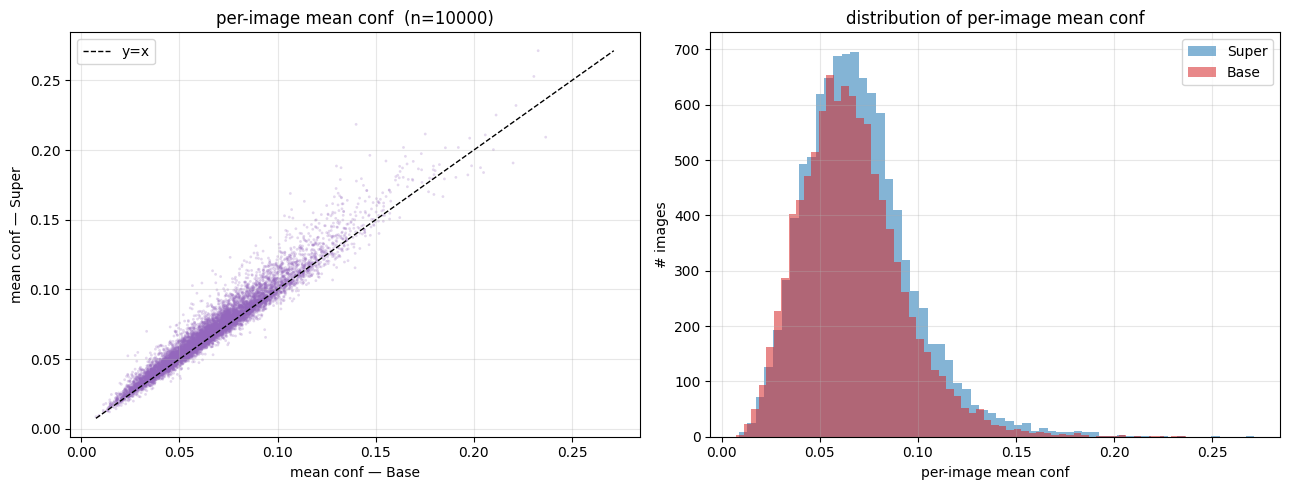

       mean_conf_super  mean_conf_base
count     10000.000000    10000.000000
mean          0.070205        0.066549
std           0.027763        0.026178
min           0.008631        0.007444
25%           0.050951        0.048163
50%           0.067125        0.063820
75%           0.084625        0.081108
max           0.271313        0.236613


In [104]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
lo = min(df_img[["mean_conf_super", "mean_conf_base"]].min())
hi = max(df_img[["mean_conf_super", "mean_conf_base"]].max())
ax.scatter(df_img["mean_conf_base"], df_img["mean_conf_super"], s=4, alpha=0.25,
           color="tab:purple", edgecolors="none")
ax.plot([lo, hi], [lo, hi], color="black", lw=1.0, ls="--", label="y=x")
ax.set_xlabel("mean conf — Base")
ax.set_ylabel("mean conf — Super")
ax.set_title(f"per-image mean conf  (n={len(df_img)})")
ax.grid(alpha=0.3); ax.legend()

ax = axes[1]
ax.hist(df_img["mean_conf_super"], bins=60, alpha=0.55, color="tab:blue", label="Super")
ax.hist(df_img["mean_conf_base"],  bins=60, alpha=0.55, color="tab:red",  label="Base")
ax.set_xlabel("per-image mean conf")
ax.set_ylabel("# images")
ax.set_title("distribution of per-image mean conf")
ax.grid(alpha=0.3); ax.legend()
fig.tight_layout()
fig.savefig(Path(OUT_DIR) / "01_image_mean_conf.png", dpi=140)
plt.show()
print(df_img[["mean_conf_super", "mean_conf_base"]].describe())

## 1b) Per-object Δconf  vs  per-image Δmean-conf

For every both-TP object: x = (super_mean − base_mean) of its image; y = that object's (conf_super − conf_base).

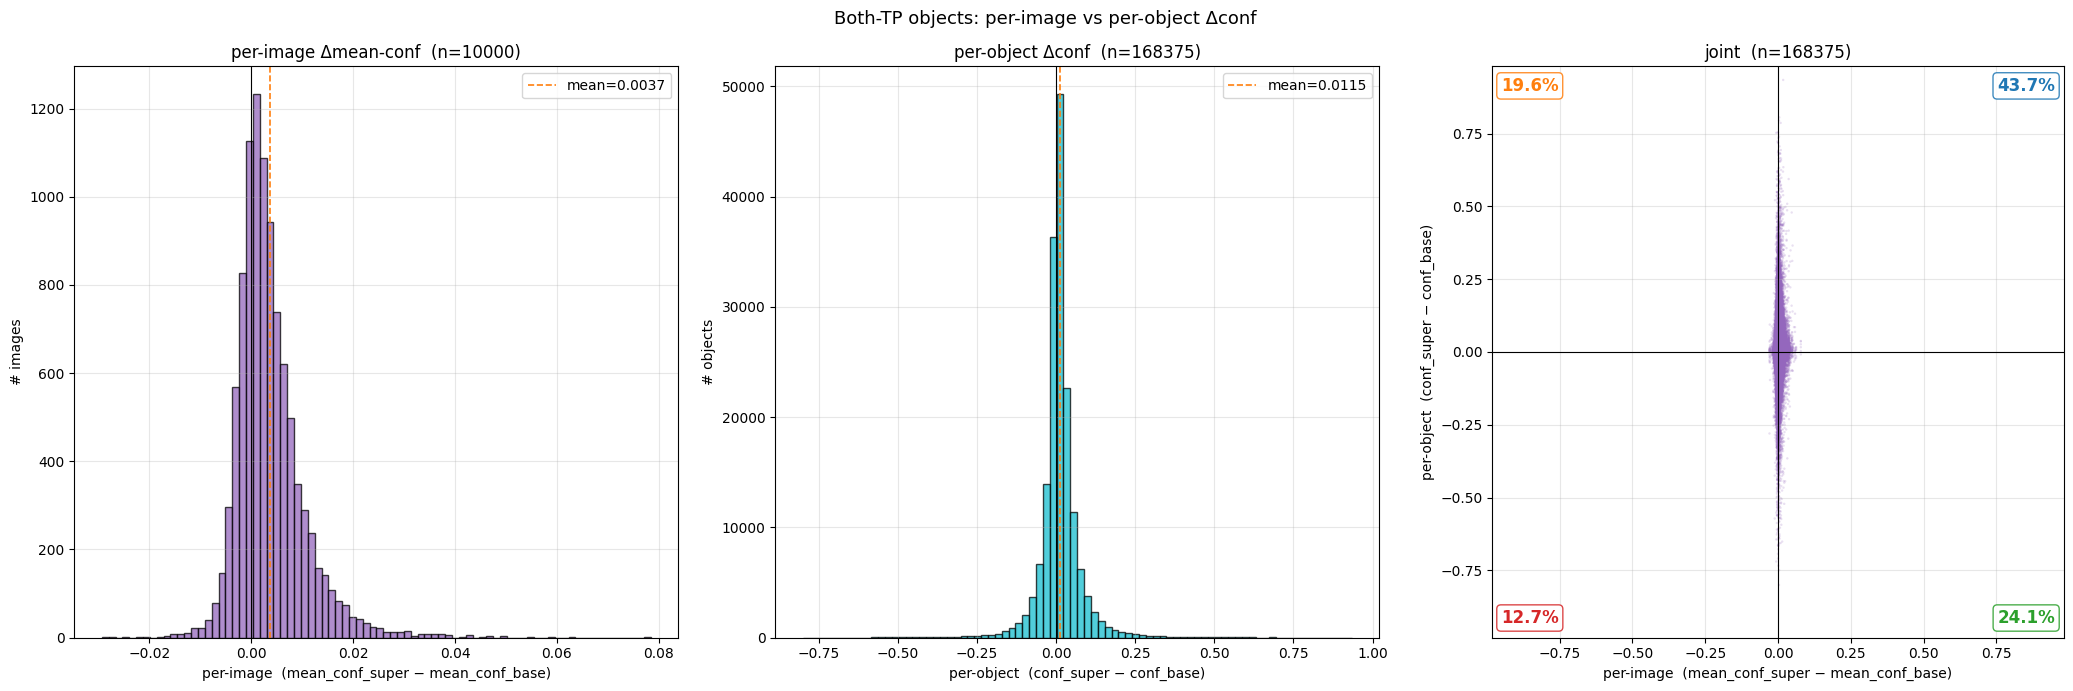

In [105]:
img_diff = (df_img["mean_conf_super"] - df_img["mean_conf_base"]).rename("img_mean_conf_diff")
img_diff_map = dict(zip(df_img["stem"], img_diff))

def _plot_three_panels(df_obj, title, save_name):
    x = df_obj["stem"].map(img_diff_map).to_numpy(dtype=float)
    y = df_obj["conf_diff"].to_numpy(dtype=float)
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]
    n = len(x)

    fig, axes = plt.subplots(1, 3, figsize=(21, 7))

    # ---- (1) per-image only: histogram of Δmean-conf ----
    ax = axes[0]
    img_d = img_diff.dropna().to_numpy()
    ax.hist(img_d, bins=80, color="tab:purple", alpha=0.75, edgecolor="black")
    ax.axvline(0, color="black", lw=0.8)
    ax.axvline(img_d.mean(), color="tab:orange", lw=1.2, ls="--",
               label=f"mean={img_d.mean():.4f}")
    ax.set_xlabel("per-image  (mean_conf_super − mean_conf_base)")
    ax.set_ylabel("# images")
    ax.set_title(f"per-image Δmean-conf  (n={len(img_d)})")
    ax.grid(alpha=0.3); ax.legend(loc="best")

    # ---- (2) per-object only: histogram of Δconf ----
    ax = axes[1]
    ax.hist(y, bins=80, color="tab:cyan", alpha=0.75, edgecolor="black")
    ax.axvline(0, color="black", lw=0.8)
    ax.axvline(y.mean(), color="tab:orange", lw=1.2, ls="--",
               label=f"mean={y.mean():.4f}")
    ax.set_xlabel("per-object  (conf_super − conf_base)")
    ax.set_ylabel("# objects")
    ax.set_title(f"per-object Δconf  (n={n})")
    ax.grid(alpha=0.3); ax.legend(loc="best")

    # ---- (3) joint scatter ----
    ax = axes[2]
    ax.scatter(x, y, s=3, alpha=0.20, color="tab:purple", edgecolors="none")
    ax.axhline(0, color="black", lw=0.8); ax.axvline(0, color="black", lw=0.8)
    lim = float(np.max(np.abs(np.concatenate([x, y])))) * 1.05 if n else 1.0
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect("equal", adjustable="box")
    if n:
        q1 = float(((x > 0) & (y > 0)).mean())
        q2 = float(((x < 0) & (y > 0)).mean())
        q3 = float(((x < 0) & (y < 0)).mean())
        q4 = float(((x > 0) & (y < 0)).mean())
        for qx, qy, val, color in [
            ( 0.97 * lim,  0.9 * lim, q1, "tab:blue"),
            (-0.97 * lim,  0.9 * lim, q2, "tab:orange"),
            (-0.97 * lim, -0.9 * lim, q3, "tab:red"),
            ( 0.97 * lim, -0.9 * lim, q4, "tab:green"),
        ]:
            ha = "right" if qx > 0 else "left"
            va = "top"   if qy < 0 else "bottom"
            ax.text(qx, qy, f"{val*100:.1f}%", ha=ha, va=va,
                    fontsize=12, fontweight="bold", color=color,
                    bbox=dict(boxstyle="round,pad=0.25",
                              fc="white", ec=color, alpha=0.85))
    ax.set_xlabel("per-image  (mean_conf_super − mean_conf_base)")
    ax.set_ylabel("per-object  (conf_super − conf_base)")
    ax.set_title(f"joint  (n={n})")
    ax.grid(alpha=0.3)

    fig.suptitle(title, fontsize=13)
    fig.tight_layout()
    fig.savefig(Path(OUT_DIR) / save_name, dpi=140)
    plt.show()

_plot_three_panels(df_tp, "Both-TP objects: per-image vs per-object Δconf",
                   "01b_obj_vs_img_confdiff_tp.png")

## 1c) Image-wise mean confidence (Super − Base)

Per image Δmean-conf, sorted ascending. Positive bar = super-net is more confident than base-net on that image.

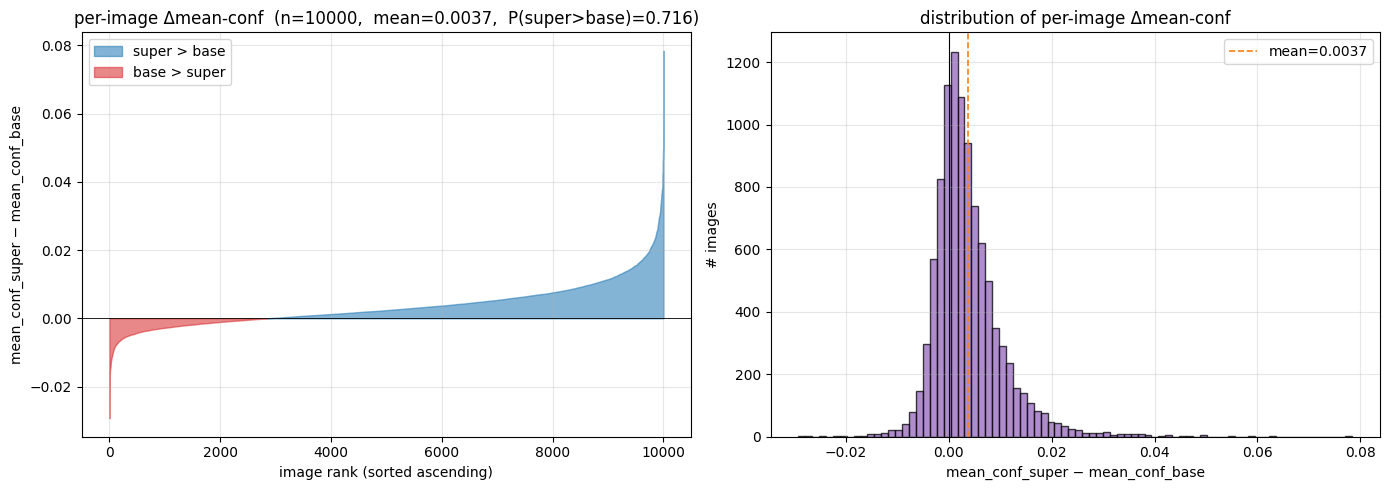

In [106]:
d = (df_img["mean_conf_super"] - df_img["mean_conf_base"]).dropna().to_numpy()
d_sorted = np.sort(d)
x = np.arange(len(d_sorted))
pos = d_sorted >= 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.fill_between(x, 0, d_sorted, where=pos,  color="tab:blue", alpha=0.55, label="super > base")
ax.fill_between(x, 0, d_sorted, where=~pos, color="tab:red",  alpha=0.55, label="base > super")
ax.axhline(0, color="black", lw=0.6)
ax.set_xlabel("image rank (sorted ascending)")
ax.set_ylabel("mean_conf_super − mean_conf_base")
ax.set_title(f"per-image Δmean-conf  (n={len(d_sorted)},  "
             f"mean={d.mean():.4f},  P(super>base)={(d>0).mean():.3f})")
ax.grid(alpha=0.3); ax.legend(loc="best")

ax = axes[1]
ax.hist(d, bins=80, color="tab:purple", alpha=0.75, edgecolor="black")
ax.axvline(0, color="black", lw=0.8)
ax.axvline(d.mean(), color="tab:orange", lw=1.2, ls="--", label=f"mean={d.mean():.4f}")
ax.set_xlabel("mean_conf_super − mean_conf_base")
ax.set_ylabel("# images")
ax.set_title("distribution of per-image Δmean-conf")
ax.grid(alpha=0.3); ax.legend(loc="best")

fig.tight_layout()
fig.savefig(Path(OUT_DIR) / "01c_image_mean_confdiff.png", dpi=140)
plt.show()

## 2) Both-TP boxes — sorted conf_diff (super − base)

Each point is one GT that both models recovered (IoU≥0.5 + class match). x-axis is the rank after sorting by `conf_super − conf_base` ascending. Two overlaid lines show the underlying super and base conf at that rank.

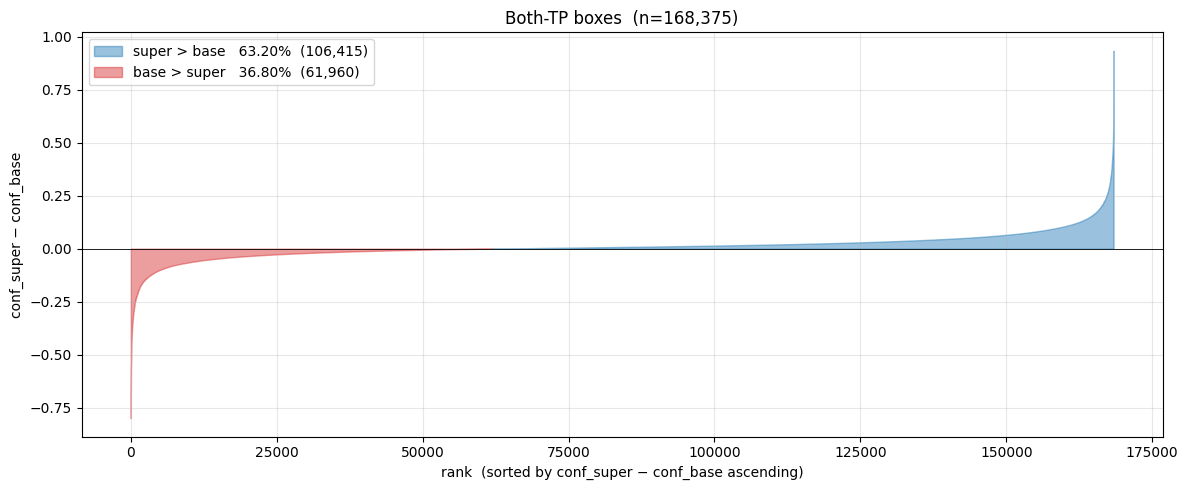

mean conf_diff (TP): 0.011526830968710447   P(super > base): 0.6320118782479585


In [107]:
def plot_sorted_pair(df_pair, title, save_name):
    d = df_pair.sort_values("conf_diff", ascending=True).reset_index(drop=True)
    x = np.arange(len(d))
    y = d["conf_diff"].to_numpy()
    pos_mask = y >= 0
    neg_mask = y <  0
    n_pos = int(pos_mask.sum())
    n_neg = int(neg_mask.sum())
    p_pos = n_pos / max(len(y), 1)
    p_neg = n_neg / max(len(y), 1)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.fill_between(x, 0, y, where=pos_mask, color="tab:blue", alpha=0.45,
                    label=f"super > base   {p_pos*100:.2f}%  ({n_pos:,d})")
    ax.fill_between(x, 0, y, where=neg_mask, color="tab:red",  alpha=0.45,
                    label=f"base > super   {p_neg*100:.2f}%  ({n_neg:,d})")
    ax.axhline(0, color="black", lw=0.6)
    ax.set_xlabel("rank  (sorted by conf_super − conf_base ascending)")
    ax.set_ylabel("conf_super − conf_base")
    ax.set_title(f"{title}  (n={len(d):,d})")
    ax.grid(alpha=0.3); ax.legend(loc="best")
    fig.tight_layout()
    fig.savefig(Path(OUT_DIR) / save_name, dpi=140)
    plt.show()

plot_sorted_pair(df_tp, "Both-TP boxes", "02_both_tp_sorted_confdiff.png")
print("mean conf_diff (TP):", df_tp["conf_diff"].mean(),
      "  P(super > base):", float((df_tp["conf_diff"] > 0).mean()))

## 3) Both-FP boxes — sorted conf_diff (super − base)

An FP from Super is paired with an FP from Base when their boxes have IoU ≥ 0.5 and the same class — i.e., both models hallucinated the same false alarm in roughly the same location. Some FPs are model-specific and don't appear here.

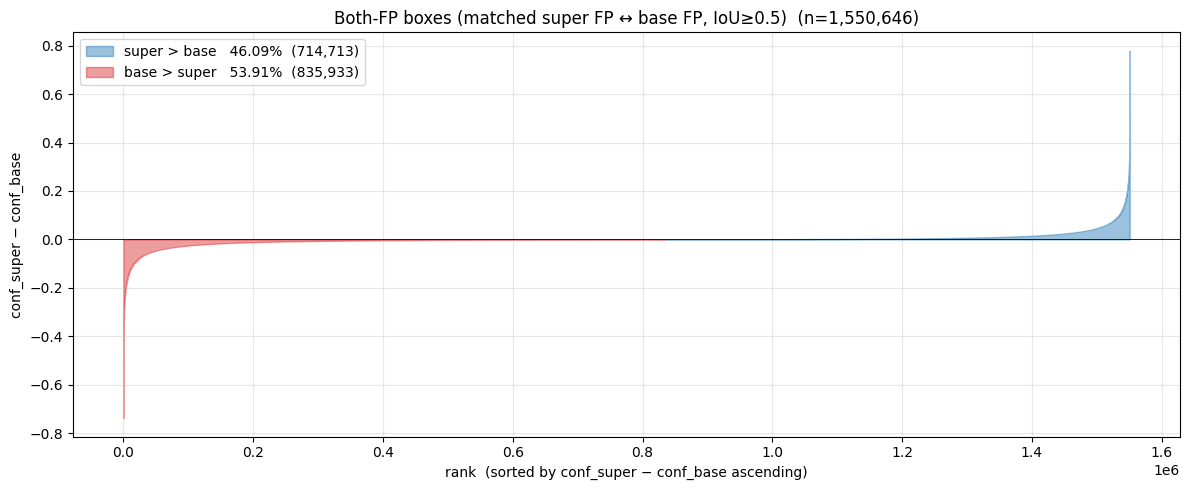

mean conf_diff (FP): -0.0002439406962994551   P(super > base): 0.46091306461951986


In [108]:
plot_sorted_pair(df_fp, "Both-FP boxes (matched super FP ↔ base FP, IoU≥0.5)",
                 "03_both_fp_sorted_confdiff.png")
print("mean conf_diff (FP):", df_fp["conf_diff"].mean(),
      "  P(super > base):", float((df_fp["conf_diff"] > 0).mean()))

## 4) Both-FN GTs (neither model recovered)

FN means the GT had no matching prediction — there's no "confidence" to plot a diff against, so we summarise the GT-side properties instead. Useful to see whether **the hard cases both models miss** are concentrated in particular classes or box sizes.

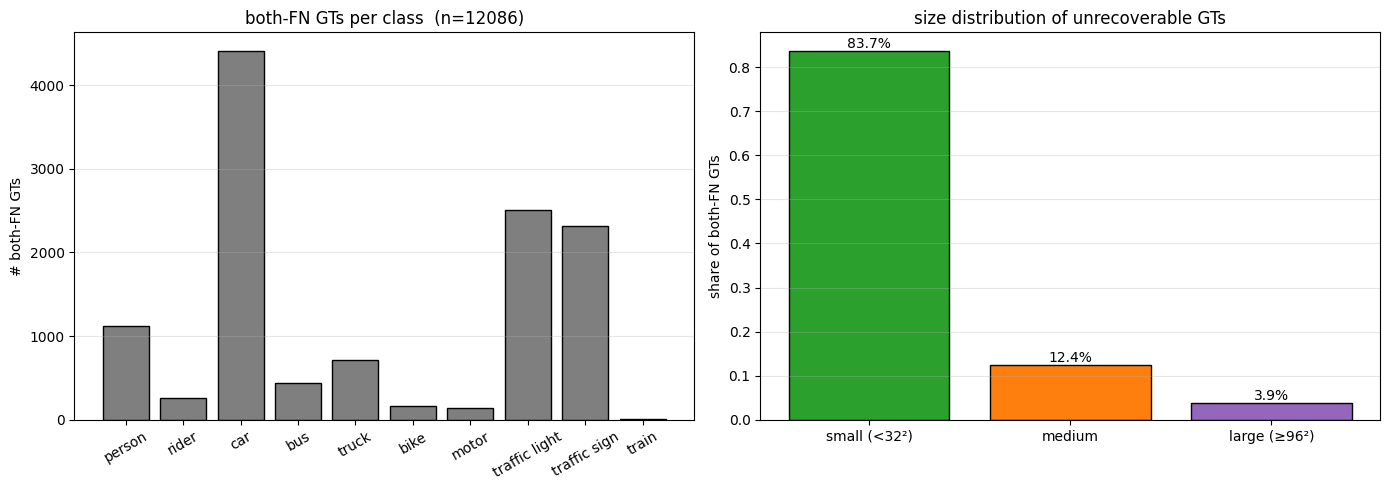

In [109]:
CLASS_NAMES = ["person", "rider", "car", "bus", "truck", "bike",
               "motor", "traffic light", "traffic sign", "train"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
vc = df_fn["cls"].value_counts().sort_index()
ax.bar([CLASS_NAMES[c] if 0 <= c < len(CLASS_NAMES) else str(c) for c in vc.index],
       vc.values, color="tab:gray", edgecolor="black")
ax.set_ylabel("# both-FN GTs")
ax.set_title(f"both-FN GTs per class  (n={len(df_fn)})")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.3)

ax = axes[1]
# COCO size buckets (in resized-image pixels at IMGSZ).
buckets = [("small (<32²)", df_fn["area"] < 32 * 32),
           ("medium",        (df_fn["area"] >= 32 * 32) & (df_fn["area"] < 96 * 96)),
           ("large (≥96²)",  df_fn["area"] >= 96 * 96)]
shares = [float(m.mean()) for _, m in buckets]
ax.bar([n for n, _ in buckets], shares,
       color=["#2ca02c", "#ff7f0e", "#9467bd"], edgecolor="black")
ax.set_ylabel("share of both-FN GTs")
ax.set_title("size distribution of unrecoverable GTs")
for i, v in enumerate(shares):
    ax.text(i, v, f"{v*100:.1f}%", ha="center", va="bottom")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(Path(OUT_DIR) / "04_both_fn_stats.png", dpi=140)
plt.show()

## Notes / caveats

- The matching for TP/FN is done **independently** for super and base (each pred greedy-matches its best class-matched GT). “Both-TP” = the same GT got a TP from both; “both-FN” = the same GT got no TP from either. So these are *per-GT* events, not *per-prediction*.
- For both-FP we additionally require the super FP and base FP to overlap (IoU≥0.5, same class) so they refer to the *same hallucinated detection*. FPs that exist only in one model are excluded by design — you asked for “둘 다”.
- `conf` here is the post-NMS top-class score, exactly as in `per_image_loss_pr_conf.py` and `eval_video_dynamic_kitti.py`.
- Both forwards are run at NMS conf ≥ 0.001, which is the standard mAP-evaluation threshold so the analysis is consistent with the AP numbers elsewhere.

## 5) Super → Base agreement rates

For every GT we record whether Super predicted it TP and whether Base predicted it TP.
For every Super-FP we record whether a class-matched, IoU≥0.5 Base-FP exists.

- **P(Base TP | Super TP)** — among the GTs Super recovered, fraction Base also recovered.
- **P(Base FP | Super FP)** — among Super's false alarms, fraction that Base also hallucinated (matched by IoU≥0.5 + class).

Also dumps per-object `conf_super − conf_base` for both conditioning sets.

[cache] loading per_gt_super_base.csv, per_super_fp.csv
GTs total            : 185578
Super TP             : 171240
  of which Base TP   : 168375   ->  P(Base TP | Super TP) = 0.9833
  of which Base FN   : 2865   ->  P(Base FN | Super TP) = 0.0167

Super FP             : 1979467
  matched Base FP    : 1550646   ->  P(Base FP | Super FP) = 0.7834
  unmatched          : 428821   ->  P(no Base FP | Super FP) = 0.2166

[both-TP conf_diff]  n=168375  mean=0.0115  median=0.0081  P(super>base)=0.6320
[both-FP conf_diff]  n=1550646  mean=-0.0002  median=-0.0003  P(super>base)=0.4609


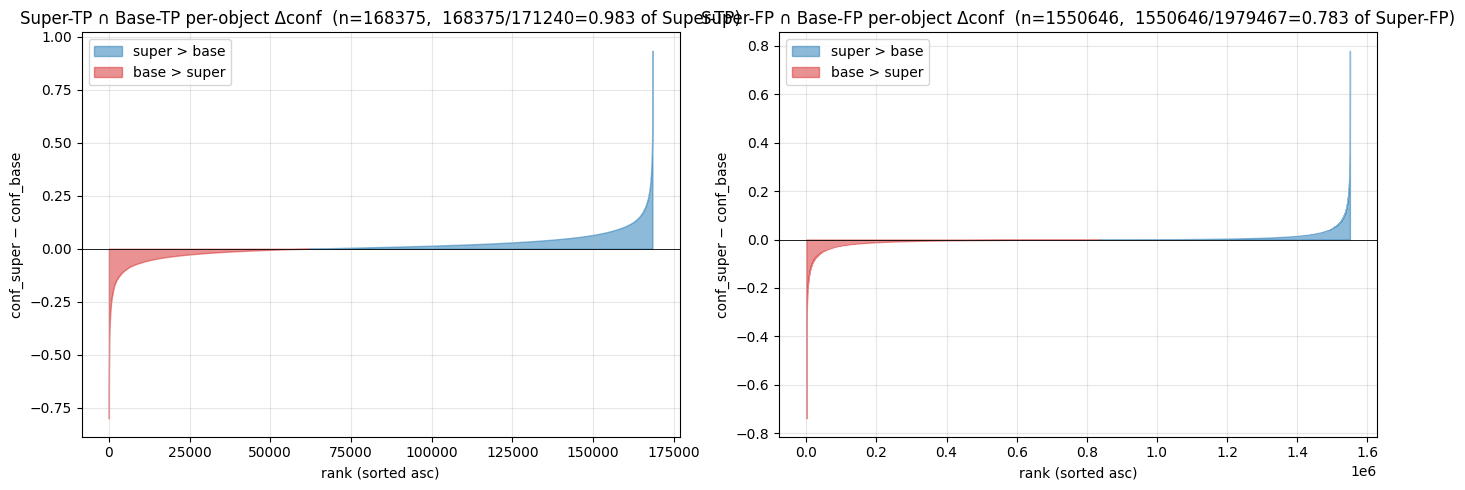

In [110]:
# ---- collect richer per-GT and per-super-FP bookkeeping ----
# Per-GT row: stem, gt_idx, cls, super_tp, base_tp, conf_super (NaN if super FN), conf_base (NaN if base FN)
# Per-super-FP row: stem, cls, conf_super, base_matched (0/1), conf_base (NaN if no match)

csv_gt   = Path(OUT_DIR) / "per_gt_super_base.csv"
csv_sfp  = Path(OUT_DIR) / "per_super_fp.csv"

if csv_gt.exists() and csv_sfp.exists():
    print(f"[cache] loading {csv_gt.name}, {csv_sfp.name}")
    df_gt  = pd.read_csv(csv_gt)
    df_sfp = pd.read_csv(csv_sfp)
else:
    gt_rows  = []
    sfp_rows = []
    with torch.no_grad():
        pbar = tqdm(loader, total=n_total)
        for i, batch in enumerate(pbar):
            if LIMIT and i >= LIMIT: break
            batch["img"] = batch["img"].to(device, non_blocking=True).float() / 255.0
            for k in ("cls", "bboxes", "batch_idx"):
                if k in batch and torch.is_tensor(batch[k]):
                    batch[k] = batch[k].to(device, non_blocking=True)
            img_h, img_w = batch["img"].shape[-2], batch["img"].shape[-1]
            gt_xywh = batch["bboxes"].clone()
            gt_xywh[:, 0] *= img_w; gt_xywh[:, 2] *= img_w
            gt_xywh[:, 1] *= img_h; gt_xywh[:, 3] *= img_h
            gt_xyxy = xywh2xyxy(gt_xywh)
            gt_cls = batch["cls"].squeeze(-1).long() if batch["cls"].numel() else batch["cls"].long()
            stem = Path(batch["im_file"][0]).stem

            preds_s = model.predict(batch["img"], skip=skip_super)
            preds_b = model.predict(batch["img"], skip=skip_base)
            raw_s = preds_s[0] if isinstance(preds_s, (list, tuple)) else preds_s
            raw_b = preds_b[0] if isinstance(preds_b, (list, tuple)) else preds_b
            det_s = run_nms(raw_s)
            det_b = run_nms(raw_b)
            pm_s, gm_s = match_preds_to_gt(det_s, gt_xyxy, gt_cls)
            pm_b, gm_b = match_preds_to_gt(det_b, gt_xyxy, gt_cls)

            for gi in range(int(gt_cls.numel())):
                ps = int(gm_s[gi].item()); pb = int(gm_b[gi].item())
                cs = float(det_s[ps, 4].item()) if ps >= 0 else float("nan")
                cb = float(det_b[pb, 4].item()) if pb >= 0 else float("nan")
                gt_rows.append((stem, gi, int(gt_cls[gi].item()),
                                int(ps >= 0), int(pb >= 0), cs, cb))

            # super FPs and try to match to base FPs (same rule as cell 5)
            fp_s_idx = (pm_s == -1).nonzero(as_tuple=False).flatten().tolist()
            fp_b_idx = (pm_b == -1).nonzero(as_tuple=False).flatten().tolist()
            if fp_s_idx:
                fp_s = det_s[fp_s_idx]
                if fp_b_idx:
                    fp_b = det_b[fp_b_idx]
                    iou_fp = box_iou(fp_s[:, :4], fp_b[:, :4])
                    cls_eq = fp_s[:, 5].long().unsqueeze(1) == fp_b[:, 5].long().unsqueeze(0)
                    iou_fp = iou_fp * cls_eq.float()
                    order_s = torch.argsort(fp_s[:, 4], descending=True)
                    used_b = torch.zeros(fp_b.shape[0], dtype=torch.bool, device=device)
                    matched_for_s = torch.full((fp_s.shape[0],), -1, dtype=torch.long, device=device)
                    for si in order_s.tolist():
                        row = iou_fp[si].clone(); row[used_b] = 0
                        bi = int(torch.argmax(row)); v = float(row[bi])
                        if v >= FP_PAIR_IOU:
                            used_b[bi] = True
                            matched_for_s[si] = bi
                    for si in range(fp_s.shape[0]):
                        bi = int(matched_for_s[si].item())
                        cb = float(fp_b[bi, 4].item()) if bi >= 0 else float("nan")
                        sfp_rows.append((stem, int(fp_s[si, 5].item()),
                                         float(fp_s[si, 4].item()),
                                         int(bi >= 0), cb))
                else:
                    for si in range(fp_s.shape[0]):
                        sfp_rows.append((stem, int(fp_s[si, 5].item()),
                                         float(fp_s[si, 4].item()), 0, float("nan")))
            pbar.set_postfix(gt=len(gt_rows), sfp=len(sfp_rows))

    df_gt  = pd.DataFrame(gt_rows,  columns=["stem","gt_idx","cls","super_tp","base_tp","conf_super","conf_base"])
    df_sfp = pd.DataFrame(sfp_rows, columns=["stem","cls","conf_super","base_matched","conf_base"])
    df_gt.to_csv(csv_gt,   index=False)
    df_sfp.to_csv(csv_sfp, index=False)

# --- ratios ---
n_super_tp = int(df_gt["super_tp"].sum())
n_both_tp  = int(((df_gt["super_tp"]==1) & (df_gt["base_tp"]==1)).sum())
n_super_fp = len(df_sfp)
n_both_fp  = int(df_sfp["base_matched"].sum())

print(f"GTs total            : {len(df_gt)}")
print(f"Super TP             : {n_super_tp}")
print(f"  of which Base TP   : {n_both_tp}   ->  P(Base TP | Super TP) = {n_both_tp/max(n_super_tp,1):.4f}")
print(f"  of which Base FN   : {n_super_tp-n_both_tp}   ->  P(Base FN | Super TP) = {1 - n_both_tp/max(n_super_tp,1):.4f}")
print()
print(f"Super FP             : {n_super_fp}")
print(f"  matched Base FP    : {n_both_fp}   ->  P(Base FP | Super FP) = {n_both_fp/max(n_super_fp,1):.4f}")
print(f"  unmatched          : {n_super_fp-n_both_fp}   ->  P(no Base FP | Super FP) = {1 - n_both_fp/max(n_super_fp,1):.4f}")

# --- per-object conf_diff (only where Base also has a conf, i.e., both-TP or both-FP) ---
m_tp = (df_gt["super_tp"]==1) & (df_gt["base_tp"]==1)
df_gt_both = df_gt.loc[m_tp, ["stem","gt_idx","cls","conf_super","conf_base"]].copy()
df_gt_both["conf_diff"] = df_gt_both["conf_super"] - df_gt_both["conf_base"]
df_gt_both.to_csv(Path(OUT_DIR)/"super_tp_and_base_tp_confdiff.csv", index=False)

m_fp = df_sfp["base_matched"]==1
df_fp_both = df_sfp.loc[m_fp, ["stem","cls","conf_super","conf_base"]].copy()
df_fp_both["conf_diff"] = df_fp_both["conf_super"] - df_fp_both["conf_base"]
df_fp_both.to_csv(Path(OUT_DIR)/"super_fp_and_base_fp_confdiff.csv", index=False)

print()
print(f"[both-TP conf_diff]  n={len(df_gt_both)}  mean={df_gt_both['conf_diff'].mean():.4f}  "
      f"median={df_gt_both['conf_diff'].median():.4f}  P(super>base)={(df_gt_both['conf_diff']>0).mean():.4f}")
print(f"[both-FP conf_diff]  n={len(df_fp_both)}  mean={df_fp_both['conf_diff'].mean():.4f}  "
      f"median={df_fp_both['conf_diff'].median():.4f}  P(super>base)={(df_fp_both['conf_diff']>0).mean():.4f}")

# --- plots: sorted conf_diff per object ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df_, title, color in [
    (axes[0], df_gt_both, f"Super-TP ∩ Base-TP per-object Δconf  (n={len(df_gt_both)},  "
                          f"{n_both_tp}/{n_super_tp}={n_both_tp/max(n_super_tp,1):.3f} of Super-TP)", "tab:blue"),
    (axes[1], df_fp_both, f"Super-FP ∩ Base-FP per-object Δconf  (n={len(df_fp_both)},  "
                          f"{n_both_fp}/{n_super_fp}={n_both_fp/max(n_super_fp,1):.3f} of Super-FP)", "tab:red"),
]:
    y = np.sort(df_["conf_diff"].to_numpy())
    x = np.arange(len(y))
    ax.fill_between(x, 0, y, where=(y>=0), color="tab:blue", alpha=0.5, label="super > base")
    ax.fill_between(x, 0, y, where=(y<0),  color="tab:red",  alpha=0.5, label="base > super")
    ax.axhline(0, color="black", lw=0.6)
    ax.set_xlabel("rank (sorted asc)")
    ax.set_ylabel("conf_super − conf_base")
    ax.set_title(title)
    ax.grid(alpha=0.3); ax.legend(loc="best")
fig.tight_layout()
fig.savefig(Path(OUT_DIR)/"05_super_cond_base_confdiff.png", dpi=140)
plt.show()

In [111]:
# ---- Super -> Base agreement: TP, FP, FN ----
# Uses df_gt (per-GT super_tp/base_tp) and df_sfp (per-super-FP, base_matched).

n_gt_total = len(df_gt)

# TP
n_super_tp = int(df_gt["super_tp"].sum())
n_tp_and   = int(((df_gt["super_tp"]==1) & (df_gt["base_tp"]==1)).sum())
r_tp = n_tp_and / max(n_super_tp, 1)

# FN  (super failed to recover the GT)
n_super_fn = int((df_gt["super_tp"]==0).sum())
n_fn_and   = int(((df_gt["super_tp"]==0) & (df_gt["base_tp"]==0)).sum())
r_fn = n_fn_and / max(n_super_fn, 1)

# FP  (per-super-FP, matched to a class-matched base FP with IoU>=FP_PAIR_IOU)
n_super_fp = len(df_sfp)
n_fp_and   = int(df_sfp["base_matched"].sum())
r_fp = n_fp_and / max(n_super_fp, 1)

print(f"Total GT boxes : {n_gt_total:>12,d}")
print()
print(f"TP : Super-TP = {n_super_tp:>12,d}   Base also TP = {n_tp_and:>12,d}   "
      f"-> P(Base TP | Super TP) = {r_tp:.4f}  ({r_tp*100:.2f}%)")
print(f"FP : Super-FP = {n_super_fp:>12,d}   Base also FP = {n_fp_and:>12,d}   "
      f"-> P(Base FP | Super FP) = {r_fp:.4f}  ({r_fp*100:.2f}%)")
print(f"FN : Super-FN = {n_super_fn:>12,d}   Base also FN = {n_fn_and:>12,d}   "
      f"-> P(Base FN | Super FN) = {r_fn:.4f}  ({r_fn*100:.2f}%)")

Total GT boxes :      185,578

TP : Super-TP =      171,240   Base also TP =      168,375   -> P(Base TP | Super TP) = 0.9833  (98.33%)
FP : Super-FP =    1,979,467   Base also FP =    1,550,646   -> P(Base FP | Super FP) = 0.7834  (78.34%)
FN : Super-FN =       14,338   Base also FN =       12,086   -> P(Base FN | Super FN) = 0.8429  (84.29%)


## Super vs Base — GT 박스 단위 탐지 결과 (exact)

각 GT 박스에 대해 super / base 각각이 TP로 검출했는지 FN(놓침)인지를 박스 identity 기준으로 집계.
전체 185,578개 GT 박스 (BDD100K val 10,000장).

### TP / FN 교집합

|  | base = TP (잡음) | base = FN (놓침) | 행 합계 |
|---|---|---|---|
| **super = TP (잡음)** | **169,846** (91.5%)<br>conf_super = 0.525<br>conf_base = 0.512<br>**Δ = −0.013** | 967 (0.5%)<br>conf_super = 0.086<br>conf_base = NaN | 170,813 |
| **super = FN (놓침)** | 2,387 (1.3%)<br>conf_super = NaN<br>conf_base = 0.125 | **12,378** (6.7%)<br>conf_super = NaN<br>conf_base = NaN | 14,765 |
| **열 합계** | 172,233 | 13,345 | **185,578** |

- **둘 다 잡음 (91.5%)** — super·base 공통 TP. base의 확신이 평균 0.013 하락.
- **super만 잡음 (0.5%)** — base가 놓친 박스. super조차 conf=0.086인 marginal 박스들.
- **base만 잡음 (1.3%)** — super가 놓쳤는데 base가 잡음. 에러 패턴이 완전히 동일하지 않음.
- **둘 다 놓침 (6.7%)** — 두 모델 모두 검출 불가한 어려운 박스.

---

### FP (헛다리 예측) 집합 분류

FP는 GT에 anchored되지 않음. super/base 각각을 앵커로 매칭해 집계.
`교집합` = 한 모델의 FP 위치에 다른 모델도 예측을 냄 (IoU≥0.5).

| 집합 | 박스 수 | conf_super | conf_base |
|---|---|---|---|
| **super FP 전체** | 1,889,349 | — | — |
| super만 (base 예측 없음) | 172,299 (9.1%) | 0.005 | NaN |
| super∩base (super 앵커) | 1,717,050 (90.9%) | 0.030 | 0.044 |
| **base FP 전체** | 1,984,500 | — | — |
| base만 (super 예측 없음) | **241,854 (12.2%)** | NaN | 0.005 |
| base∩super (base 앵커) | 1,742,646 (87.8%) | 0.045 | 0.031 |

> 교집합 카운트가 앵커 방향마다 다른 이유: IoU 매칭이 비대칭 (각 방향에서 "최선의 상대"를 찾으므로).

---

### 핵심 관찰 — TP와 FP에서 conf 방향이 반대

| | conf 변화 (base − super) | 해석 |
|---|---|---|
| **TP 교집합** | **−0.013** (↓) | base는 정답 박스에 덜 확신함 |
| **FP 교집합** | **+0.014** (↑) | base는 헛다리 박스에 더 확신함 |

두 방향이 반대 → **base가 잃는 건 정답에 대한 확신이지, 헛다리에 대한 확신이 아니다.**
"base는 틀린 걸 더 자신만만하게 치고, 맞는 걸 더 주저하며 친다."

---

**결론:** 탐지 커버리지(TP/FN)에서 super·base는 91.5% 동일. base가 잃는 것은 박스를 찾는 능력이 아니라 **찾은 박스에 대한 confidence**다 — 그것도 **정답 박스에서만 선택적으로.**